# Tuning
This notebook summarises the workflow of tuning and tracking resonators using `sodetlib`. This is typically all you need,
but it won't give you all the information to understand what is going on under the hood. The step-by-step process is
available in [the docs](https://sodetlib.readthedocs.io/en/latest/operations/setup.html).

You can find more details in [The Appendix notebook](./Appendix.ipynb)
and in the [`sodetlib` docs](https://sodetlib.readthedocs.io/en/latest/interactive_setup.html#tuning-on-resonators).

In [1]:
import matplotlib
matplotlib.use("Agg")
%matplotlib inline

/opt/venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import numpy as np
import time
import pysmurf.client
import matplotlib.pyplot as plt
from sodetlib.det_config import DetConfig

Rogue/pyrogue version v6.13.0. https://github.com/slaclab/rogue


To start tuning the first step is to instantiate a SmurfControl object. Typcally, this is stored under the variable S.

To load the SmurfControl object, use the DetConfig class described in the sodetlib tutorial. This will pull
configuration files from your `$SMURF_CONFIG_DIR` and correctly load a SmurfControl object for the specified
slot.  

Additional keyword arguments can be passed to the SmurfControl class via this function. See the [SmurfControl](https://pysmurf.readthedocs.io/en/main/client/base.html#module-pysmurf.client.base.smurf_control) docs for more info on allowed parameters.

In [3]:
cfg = DetConfig()
cfg.load_config_files(slot=4)
S = cfg.get_smurf_control(dump_configs=True, make_logfile=True)

Connected to AMCc at localhost:9012
Dumping sodetlib configs to /data/smurf_data/20260609/crate1slot4/1781046527/config/1781046527


This SmurfControl object is the way in which we interact with the Cryostat. In the rest of this notebook we will walk through starting up a slot and tuning resonators.

These operations are collected at a high level in the `sodetlib.uxm_setup` module.

In [6]:
from sodetlib import uxm_setup

## Setting Amplifier Biases
Target amplifier bias currents should be set in your device config file:

In [7]:
print(f"50k target current: {cfg.dev.exp['amp_50k1_drain_current']}\tHemt target current: {cfg.dev.exp['amp_hemt1_drain_current']}")

50k target current: 21.5	Hemt target current: 4


The `setup_amps` function will scan over gate voltages to optimise the drain currents to these targets.

In [8]:
# note this amp is different from the SO ones and we need to
# adjust the range for the optimisation to succeed
uxm_setup.setup_amps(S, cfg, opt_args={"vg_max": 1.0})

(True,
 {'success': True,
  '50k1_gate_volt': 0.0,
  '50k1_drain_volt': 5.000003766174316,
  '50k1_drain_current': 21.51908892134152,
  '50k1_enable': True,
  '50k2_gate_volt': 0.0,
  '50k2_drain_volt': 0.0,
  '50k2_drain_current': -0.024510925067982692,
  '50k2_enable': False,
  'hemt1_gate_volt': 0.31998833328000004,
  'hemt1_drain_volt': 0.5000014869880673,
  'hemt1_drain_current': 3.853535131646876,
  'hemt1_enable': True,
  'hemt2_gate_volt': 0.0,
  'hemt2_drain_volt': 0.0,
  'hemt2_drain_current': -0.0884517036654621,
  'hemt2_enable': False})

If you need to adjust these manually, you can use the `pysmurf` functions:

In [11]:
# aim for 4mA
S.set_amp_drain_voltage('hemt1',0.5)
S.set_amp_gate_voltage('hemt1',0.27,override=True)

# Bias RFC1 50K LNA -- aim for 21mA
S.set_amp_drain_voltage('50k1',5.0)
S.set_amp_gate_voltage('50k1',0.0)

print(S.get_amplifier_biases()) 

{'50k1_gate_volt': 0.0, '50k1_drain_volt': 5.000003766174316, '50k1_drain_current': 21.508269918924363, '50k1_enable': True, '50k2_gate_volt': 0.0, '50k2_drain_volt': 0.0, '50k2_drain_current': -0.0461489299023064, '50k2_enable': False, 'hemt1_gate_volt': 0.26999620208, 'hemt1_drain_volt': 0.5000014869880673, 'hemt1_drain_current': 3.913429620547238, 'hemt1_enable': True, 'hemt2_gate_volt': 0.0, 'hemt2_drain_volt': 0.0, 'hemt2_drain_current': -0.08179676045431086, 'hemt2_enable': False}


You can turn off power to an amplifier by disabling its drain power.

In [12]:
# only run this if you want this amp off
S.set_amp_drain_enable("50k1", False)

## Setting controllable attenuation
There are tunable attenuators at the input and output of the cryostat that can be used to optimise the signal level
when it reaches the ADC. We start by setting them to some mid-range values and can adjust later.

In [9]:
bands = [0, 1, 2, 3]  # In this example we have devices connected to the AMC 0
uc_atts={}
dc_atts={}

# SMB resonators on band 0
uc_atts[0]=24
dc_atts[0]=22

# SPB resonators on band 3
uc_atts[3]=12
dc_atts[3]=0

# these have no resonators so we will add more attenuation
for b in [1, 2]:
    uc_atts[b]=14
    dc_atts[b]=14

for band in bands:
    S.set_att_uc(band,uc_atts[band]) # 0.5dB per step
    S.set_att_dc(band,dc_atts[band]) # 0.5dB per step
    cfg.dev.bands[band]["uc_att"] = uc_atts[band]
    cfg.dev.bands[band]["dc_att"] = dc_atts[band]

    print(S.get_att_uc(band))
    print(S.get_att_dc(band))

24
22
14
14
14
14
12
0


We can take a quick look at the signal level

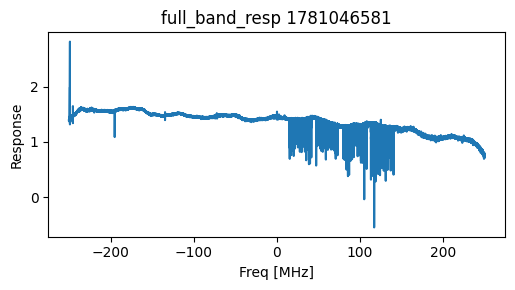

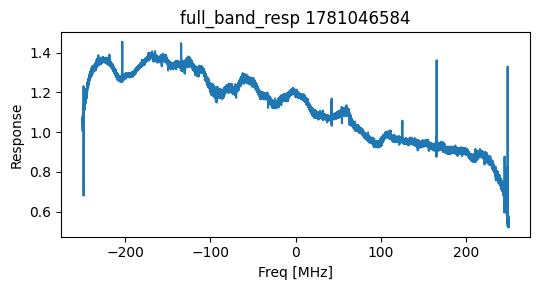

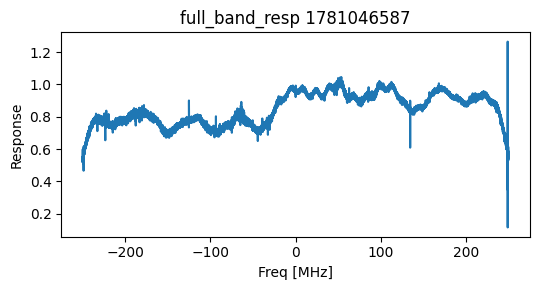

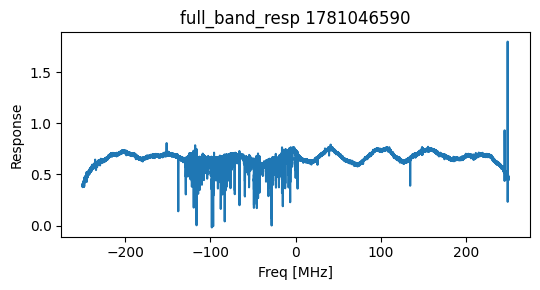

In [10]:
for b in bands:
    S.full_band_resp(b, make_plot=True, show_plot=True)

## Tuning with `sodetlib`

First, `setup_phase_delay` will measure the total delay (cable transmission and digital processing) in the system.

In [11]:
bands = [0, 3]  # only resonators on bands 0 and 3 in this case

In [12]:
uxm_setup.setup_phase_delay(S, cfg, bands)

-------------------------------------------------------
Estimated cable_delay_us=0.73153291697249
Estimated dsp_delay_us=8.477298455703341
Estimated processing_delay_us=7.745765538730851
-------------------------------------------------------
-------------------------------------------------------
Estimated cable_delay_us=0.7328933660690926
Estimated dsp_delay_us=8.65198159292245
Estimated processing_delay_us=7.919088226853358
-------------------------------------------------------


(True,
 {'bands': [0, 3], 'band_delay_us': [8.477298455703341, 8.65198159292245]})

If you get an error complaining about ADC saturation at this step, you probably need to add more attenuation.

Next, `setup_tune` will perform resonator tuning by stepping through:
- a coarse scan of each band to identify resonator locations
- a finer scan and gradient descent algorithm to pin point each resonance center frequency
- a measurement of the `eta` parameter to calibrate the measured $S_{21}$ into a center frequency shift

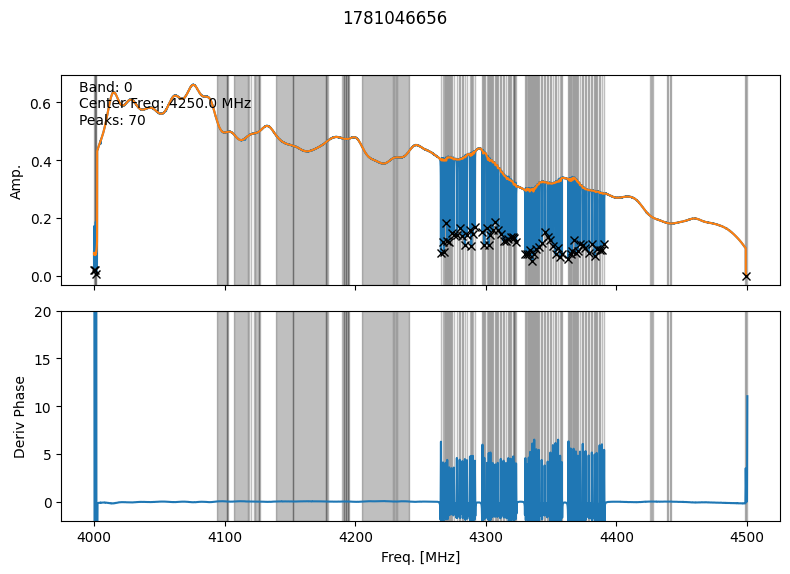

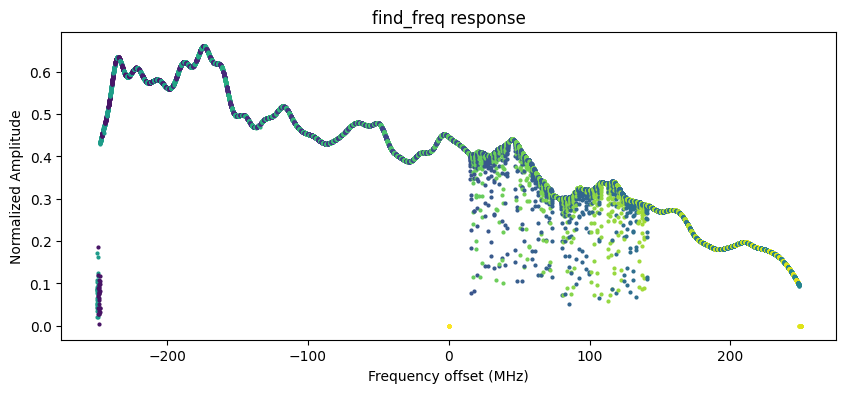

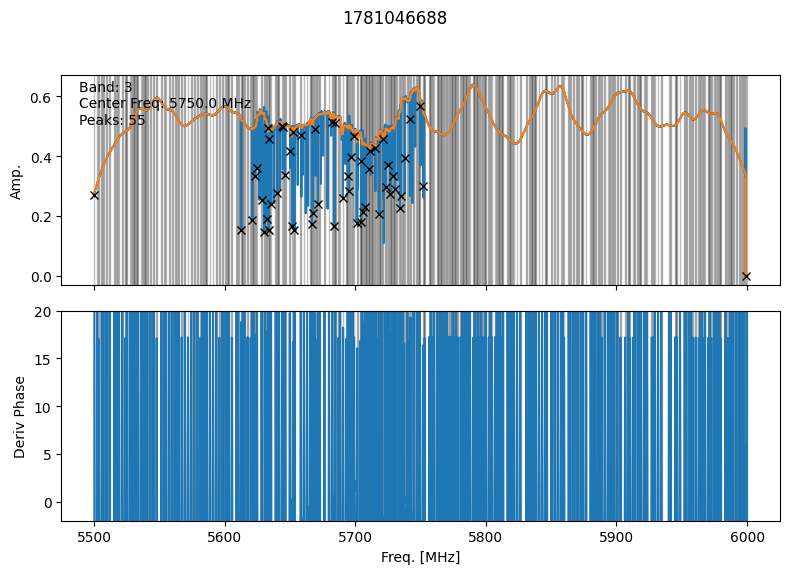

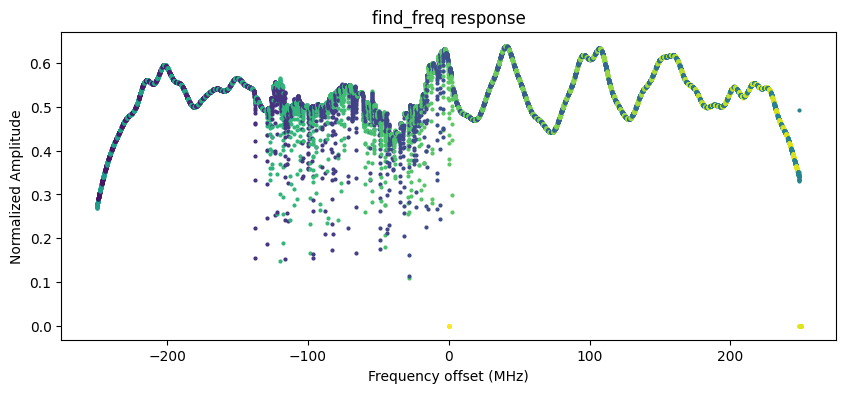

(True, {})

In [13]:
uxm_setup.setup_tune(S, cfg, bands, show_plots=True, update_cfg=True)

## Tracking Setup with `sodetlib`
The following function finds tracking parameters for the tracking configuration in the device config.

Refer to the [`sodetlib` config](https://sodetlib.readthedocs.io/en/latest/operations/setup.html#id3).

In [14]:
from sodetlib.operations import tracking

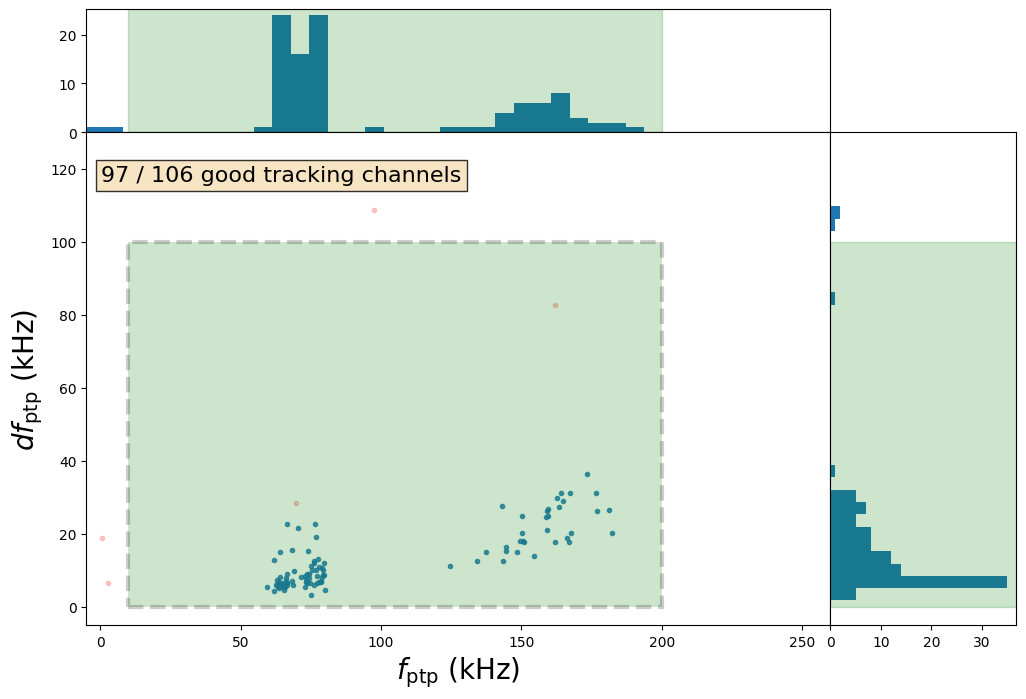

In [15]:
tracking.setup_tracking_params(S, cfg, bands, show_plots=True, update_cfg=True)

Under the hood, this function is optimizing parameters that go into the `pysmurf` `tracking_setup` method.
You can also run this explicitly and inspect tracking plots for individual resonators.

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(629, 512)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(629, 512)),
 array([[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]], shape=(262144, 2)))

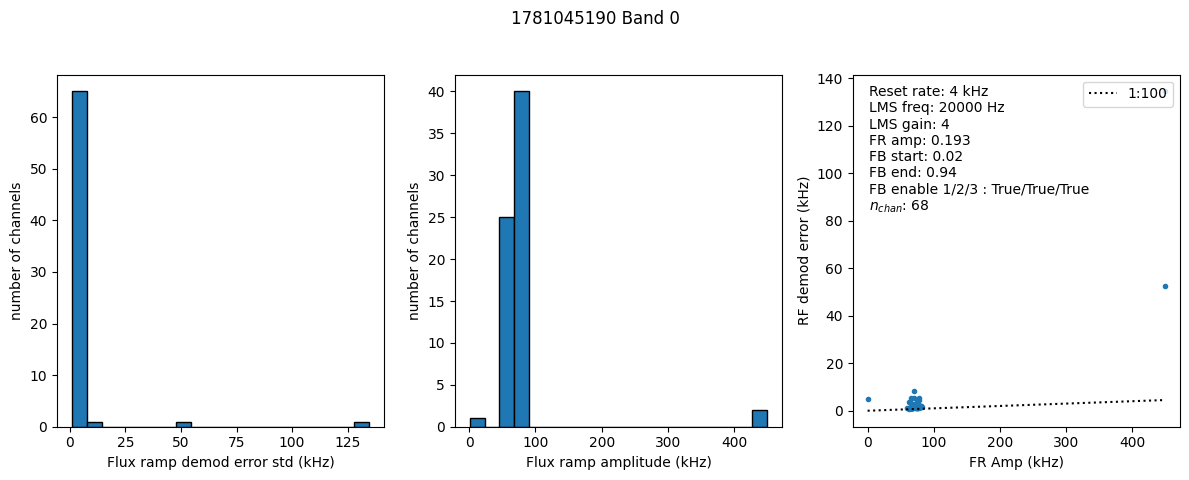

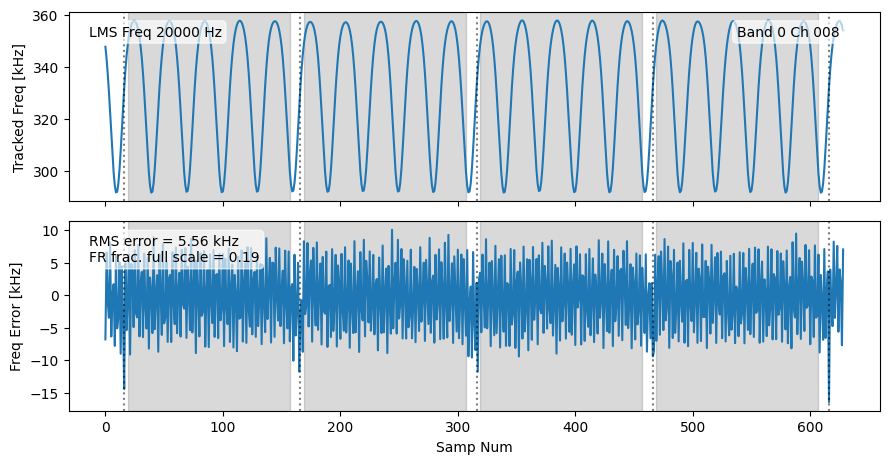

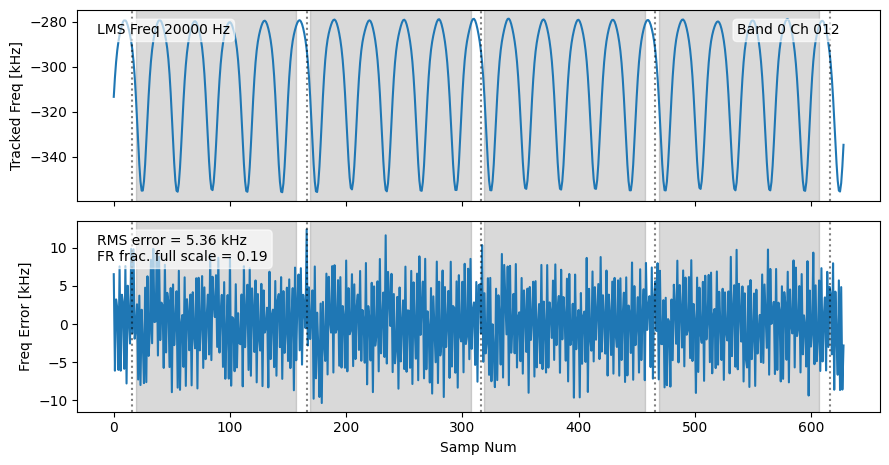

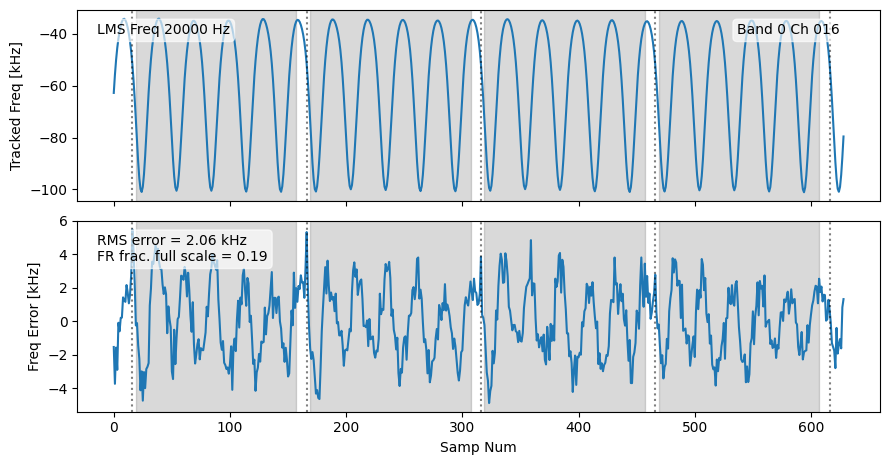

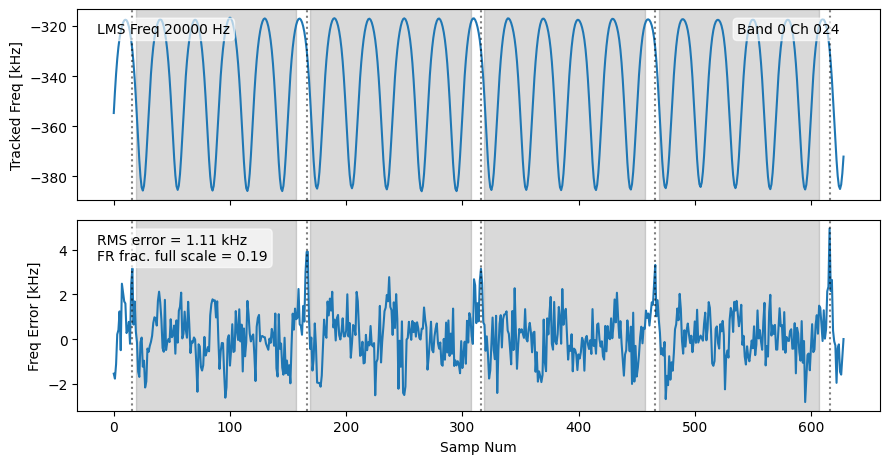

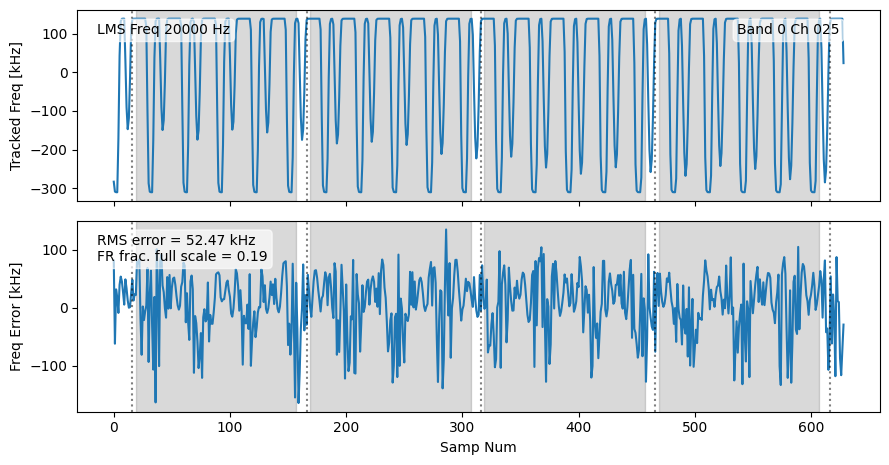

In [46]:
band = 0
band_cfg = cfg.dev.bands[band]
S.tracking_setup(band,reset_rate_khz=4,lms_freq_hz=band_cfg['lms_freq_hz'],meas_lms_freq=False,
                 fraction_full_scale=band_cfg['frac_pp'],make_plot=True,show_plot=True,
                 channel=S.which_on(band)[:5],nsamp=2**18,feedback_start_frac=0.02,feedback_end_frac=0.94);

Now we should be tracking well and ready to use our readout system (i.e. stream data for noise, bolometer signals, etc.).

If you want to kill channels by hand you just flip through the individual channel plots and write down into a list the channels that look like they're tracking poorly then turn them off. I'll call this list of bad channel, `bad_chans`.

In [ ]:
bad_chans = []
for chan in bad_chans:
    S.channel_off(band,chan)

## Streaming Data
After killing poorly tracking channels you can now stream data, this can be done in a few ways:
- **take_noise_psd** takes a timestream of specified length then calculates its ASD and fits for white noise level, $f_{knee}$, and the low frequency noise power law index. It also produces some nice summary plots and we often use the summary plot as a check that we're getting a median white noise levl we expect (for resonator only channels this should be ~30-40pA/rtHz)
- **take_stream_data** takes a timestream of specified length
- **stream_data_on/off** streams data indefinitely until stopped

The next two tutorial notebooks delve into data-taking in more depth.

In [49]:
S.take_noise_psd(meas_time=10,low_freq=[1],high_freq=[10],nperseg=2**16,
                 save_data=True,show_plot=True,make_channel_plot=True,
                 channel = S.which_on(band)[:5])

KeyboardInterrupt: 

In [50]:
datfile_tsd = S.take_stream_data(10)

In [ ]:
datfile_sdo = S.stream_data_on()
time.sleep(10)
S.stream_data_off()

## Relocking a tune

If a tune file has been generated already, it is not necessary to go through the the full tuning process again.
The `uxm_relock` operation will:
1. Reset state (all off, disable waveform, etc.)
2. Set amps and check tolerance
3. load tune, setup_notches, serial grad descent and eta scan
4. Tracking setup
5. Measure noise

It is documented [here](https://sodetlib.readthedocs.io/en/latest/operations/setup.html#relocking).

In [60]:
from sodetlib.operations import uxm_relock

uxm_relock.uxm_relock(S, cfg, bands, skip_setup_amps=True, show_plots=True)

Skipping amp setup


IndexError: index 0 is out of bounds for axis 0 with size 0

## Bonus: Loopback measurements
If you don't have access to cold resonators, it can sometimes be useful to put the system into
loopback, i.e. directly connect the input and output of the AMC. In this examples, AMC 1 is in this
configuration. We can use the SMuRF to sweep over bands in loopback.

`estimate_phase_delay` measures and corrects for line delay (we set this using `sodetlib` for other band above).

In [ ]:
band = 4  # this is on AMC 1

-------------------------------------------------------
Estimated cable_delay_us=0.6732049498378384
Estimated dsp_delay_us=8.412441994386405
Estimated processing_delay_us=7.739237044548567
-------------------------------------------------------


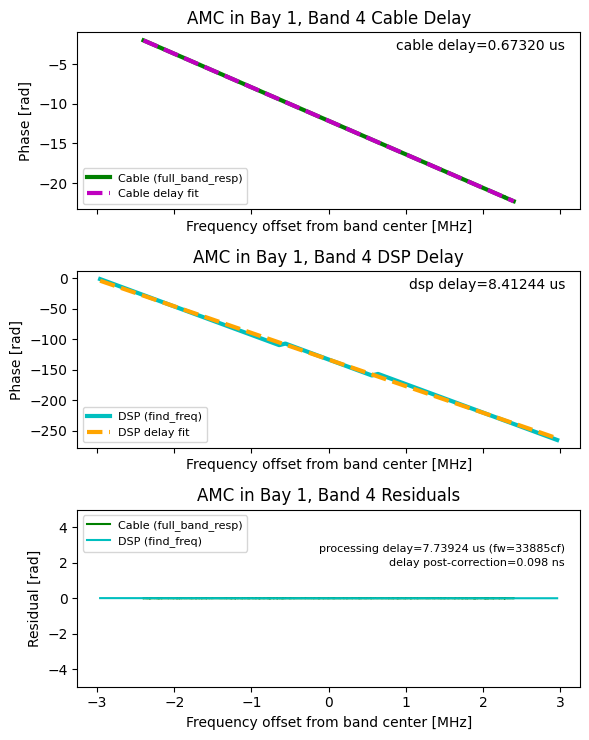

(np.float64(8.412441994386405), np.float64(9.792135974086953e-05))

In [54]:
S.estimate_phase_delay(band, make_plot=True, show_plot=True)

`find_freq` performs a fine sweep:

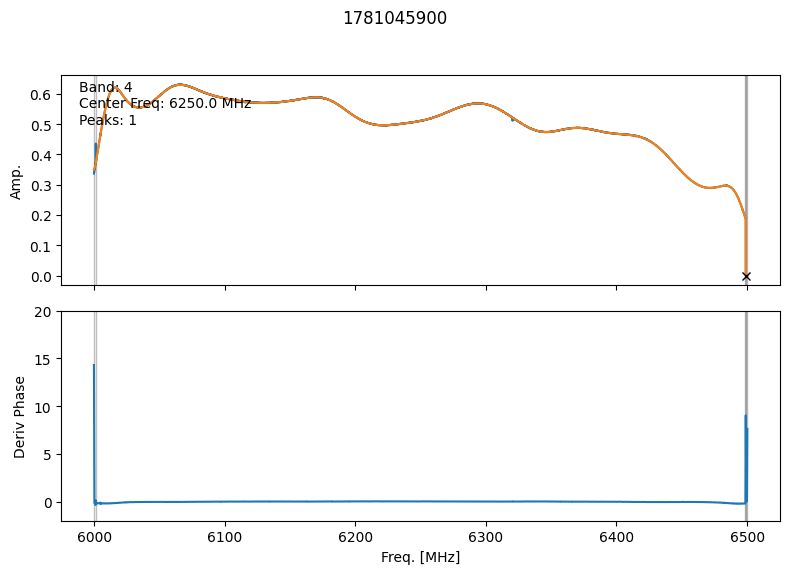

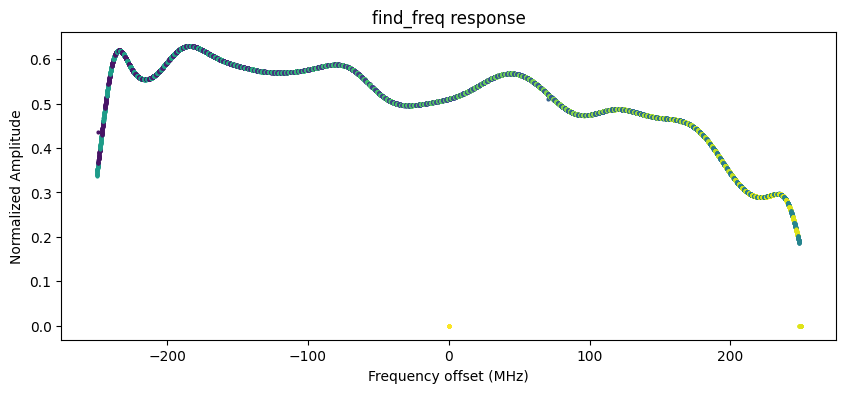

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(512, 31)),
 array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        ...,
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],
       shape=(512, 31)))

In [55]:
S.find_freq(band, make_plot=True, show_plot=True)

`full_band_resp` performs a coarser (faster) sweep:

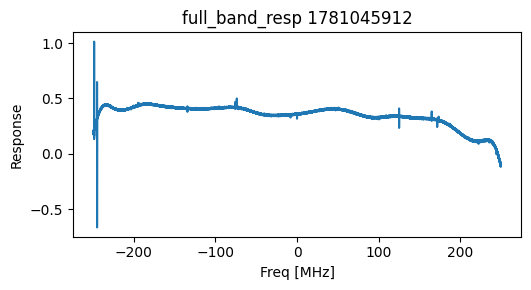

(array([-3.07200000e+08, -3.07197656e+08, -3.07195312e+08, ...,
         3.07192969e+08,  3.07195312e+08,  3.07197656e+08], shape=(262144,)),
 array([-0.00373089-0.0013075j , -0.00181362-0.00176822j,
        -0.00247381-0.00027428j, ..., -0.00246041+0.00181359j,
        -0.00260136-0.00144106j, -0.00232678-0.0015187j ], shape=(262144,)))

In [56]:
S.full_band_resp(band, show_plot=True, make_plot=True)